In [1]:
!git clone https://github.com/RudraKsh0091/AI-Image-Impainting.git
%cd AI-Image-Impainting
!pip install -r requirements.txt

Cloning into 'AI-Image-Impainting'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 101 (delta 52), reused 50 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 19.78 KiB | 4.94 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/kaggle/working/AI-Image-Impainting


In [2]:
import tensorflow as tf
print(tf.__version__)  # should print 2.19.0

2026-06-20 13:49:22.897359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781963363.100739      77 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781963363.164302      77 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781963363.680032      77 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781963363.680067      77 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781963363.680069      77 computation_placer.cc:177] computation placer alr

2.19.0


In [3]:
import numpy as np
print(np.__version__)

2.4.6


In [4]:
def denormalize_image(img):
    img = (img + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

In [6]:
from src.model import build_unet
from src.data import get_train_val_split, load_dataset
from src import config

model = build_unet(img_size=config.IMG_SIZE)
model.load_weights("/kaggle/input/datasets/rudraksh00/base-model/best_model.weights.h5")

In [7]:
_, val_paths = get_train_val_split(config.IMAGE_DIR, num_train=config.NUM_TRAIN, num_val=config.NUM_VAL)
val_ds = load_dataset(val_paths[:8], img_size=config.IMG_SIZE, batch_size=8, mask_type='combined', fixed_seed=123)

for (masked_images, masks), originals in val_ds.take(1):
    predictions = model.predict([masked_images, masks])
    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [8]:
predictions.shape

(8, 256, 256, 3)

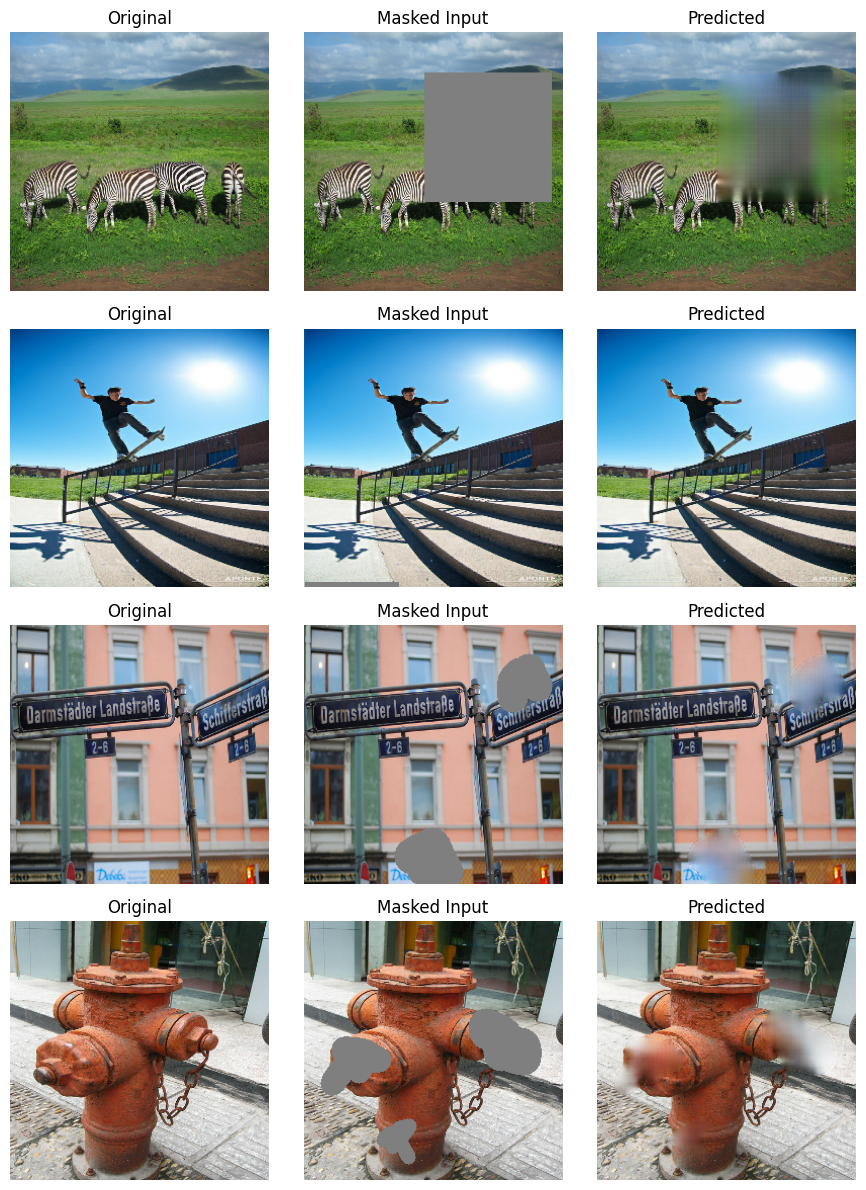

In [9]:
import matplotlib.pyplot as plt

num_samples = 4
fig, axes = plt.subplots(num_samples, 3, figsize=(9, num_samples * 3))

for i in range(num_samples):
    original = denormalize_image(originals[i].numpy())
    masked = denormalize_image(masked_images[i].numpy())
    predicted = denormalize_image(predictions[i])

    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(masked)
    axes[i, 1].set_title("Masked Input")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(predicted)
    axes[i, 2].set_title("Predicted")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("evaluation_grid.png", dpi=150)
plt.show()